# 04 - Allen-Cahn Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t = \varepsilon^2 u_{xx} + u - u^3$, $\varepsilon = 0.01$

**IC:** $u(x,0) = x^2 \cos(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 128, 128, 128, 128, 128, 1]` | **Epochs:** 10000

**Note:** Allen-Cahn is the hardest test. Stiff PDE with sharp interface.
Vanilla PINN is known to fail here. This is AC-PINN's strongest showcase.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    AllenCahnFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'allen_cahn'
LAYERS     = [2, 128, 128, 128, 128, 128, 1]
EPOCHS     = 10000
PDE_PARAMS = {'epsilon': 0.01}
RESULTS    = '../results/allen_cahn/'
FIGURES    = '../figures/allen_cahn/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

AllenCahnFDM solved in 1.6733s


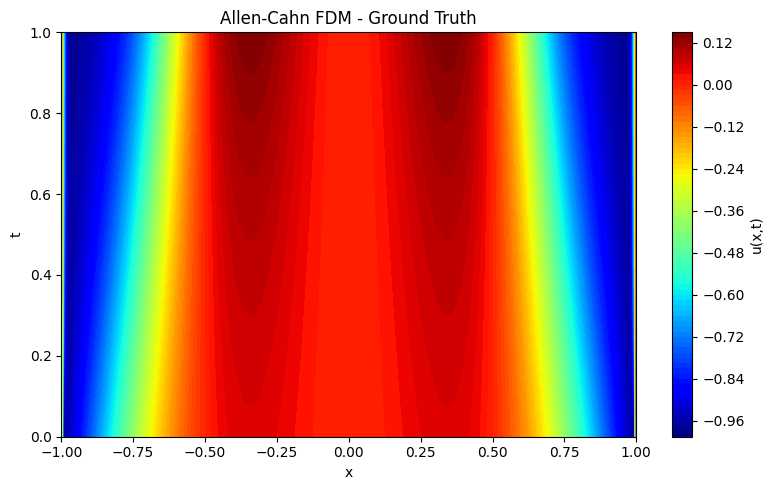

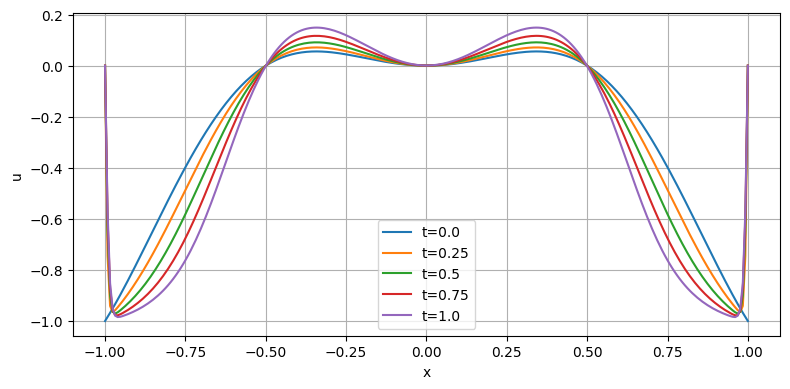

In [2]:
fdm = AllenCahnFDM(nx=256, nt=5000, epsilon=0.01)
fdm.solve()
fdm.plot_solution(title='Allen-Cahn FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
# Allen-Cahn needs more collocation points due to stiffness
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=10000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=3000,  noise_eps=0.1)
print('Data ready')

Data ready


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Allen-Cahn | Vanilla Clean | Epoch     0/10000] Total: 0.160363 | IC: 0.146396 | BC: 0.002503 | PDE: 0.001146


[Allen-Cahn | Vanilla Clean | Epoch  1000/10000] Total: 0.135903 | IC: 0.128396 | BC: 0.004197 | PDE: 0.000331


[Allen-Cahn | Vanilla Clean | Epoch  2000/10000] Total: 0.135807 | IC: 0.128831 | BC: 0.003974 | PDE: 0.000300


[Allen-Cahn | Vanilla Clean | Epoch  3000/10000] Total: 0.135916 | IC: 0.128390 | BC: 0.004144 | PDE: 0.000338


...

[Allen-Cahn | Vanilla Clean | Epoch  6000/10000] Total: 0.037342 | IC: 0.029117 | BC: 0.003831 | PDE: 0.000439


[Allen-Cahn | Vanilla Clean | Epoch  7000/10000] Total: 0.020732 | IC: 0.017141 | BC: 0.000953 | PDE: 0.000264


[Allen-Cahn | Vanilla Clean | Epoch  8000/10000] Total: 0.021873 | IC: 0.014171 | BC: 0.004898 | PDE: 0.000280


[Allen-Cahn | Vanilla Clean | Epoch  9000/10000] Total: 0.016001 | IC: 0.010641 | BC: 0.003631 | PDE: 0.000173



Training complete in 252.59s


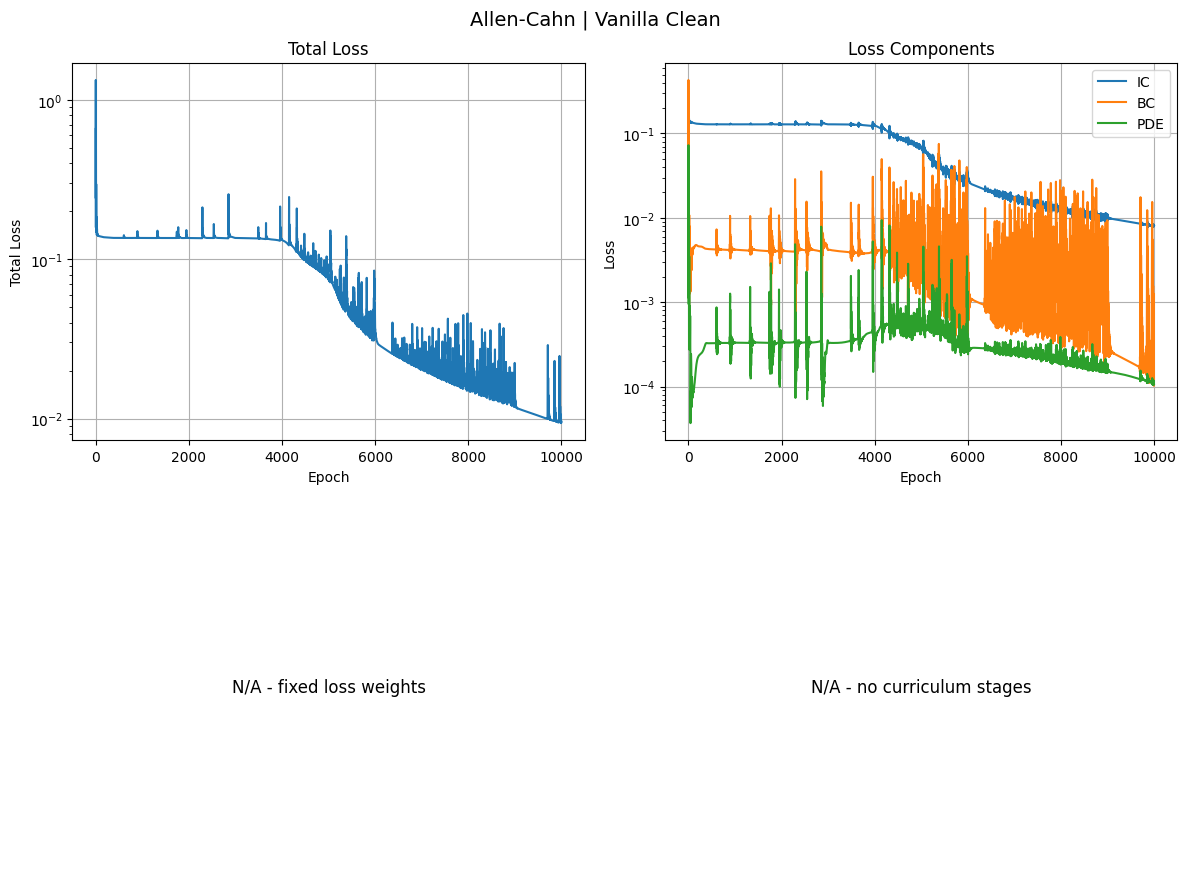

Saved: ../figures/allen_cahn/vanilla_clean_training.png
Saved: ../figures/allen_cahn/vanilla_clean_training.csv


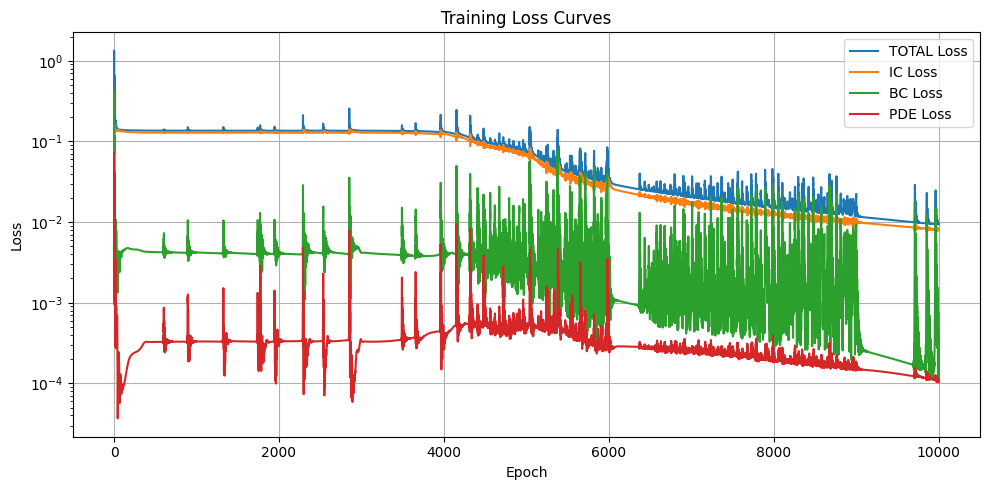

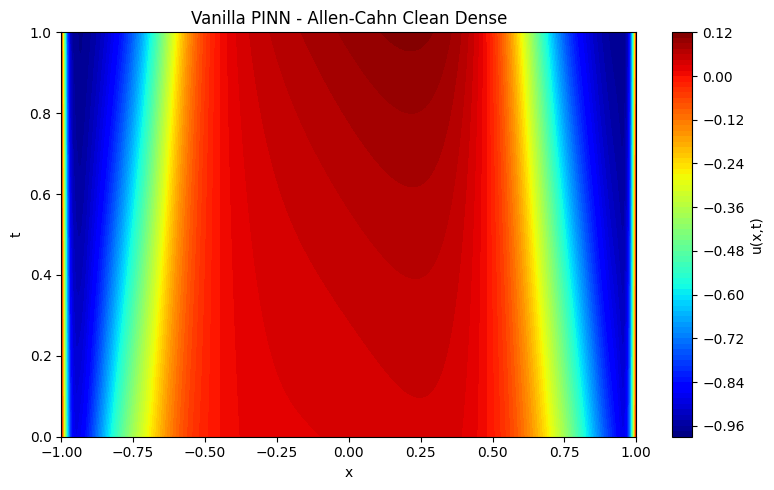

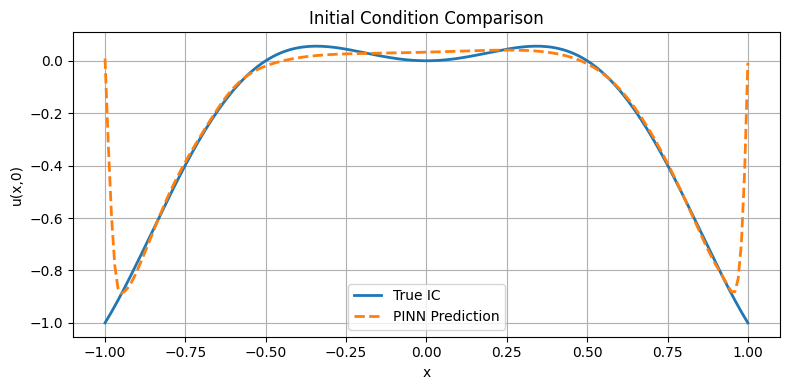

Saved: ../results/allen_cahn/vanilla_clean_history.npy


In [4]:
# Higher lambda_pde for stiff PDE
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Allen-Cahn | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Allen-Cahn Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse
⚠️ Vanilla PINN typically fails here on Allen-Cahn.

[Allen-Cahn | Vanilla Noisy | Epoch     0/10000] Total: 0.466738 | IC: 0.164254 | BC: 0.102173 | PDE: 0.020031


[Allen-Cahn | Vanilla Noisy | Epoch  1000/10000] Total: 0.168768 | IC: 0.145351 | BC: 0.020793 | PDE: 0.000262


[Allen-Cahn | Vanilla Noisy | Epoch  2000/10000] Total: 0.168579 | IC: 0.145368 | BC: 0.020773 | PDE: 0.000244


[Allen-Cahn | Vanilla Noisy | Epoch  3000/10000] Total: 0.169199 | IC: 0.146444 | BC: 0.021257 | PDE: 0.000150


[Allen-Cahn | Vanilla Noisy | Epoch  4000/10000] Total: 0.168617 | IC: 0.145254 | BC: 0.020993 | PDE: 0.000237


...

[Allen-Cahn | Vanilla Noisy | Epoch  6000/10000] Total: 0.084945 | IC: 0.065828 | BC: 0.017231 | PDE: 0.000189


[Allen-Cahn | Vanilla Noisy | Epoch  7000/10000] Total: 0.073620 | IC: 0.055203 | BC: 0.015159 | PDE: 0.000326


[Allen-Cahn | Vanilla Noisy | Epoch  8000/10000] Total: 0.027379 | IC: 0.008525 | BC: 0.013724 | PDE: 0.000513


[Allen-Cahn | Vanilla Noisy | Epoch  9000/10000] Total: 0.020486 | IC: 0.004768 | BC: 0.013385 | PDE: 0.000233



Training complete in 132.36s


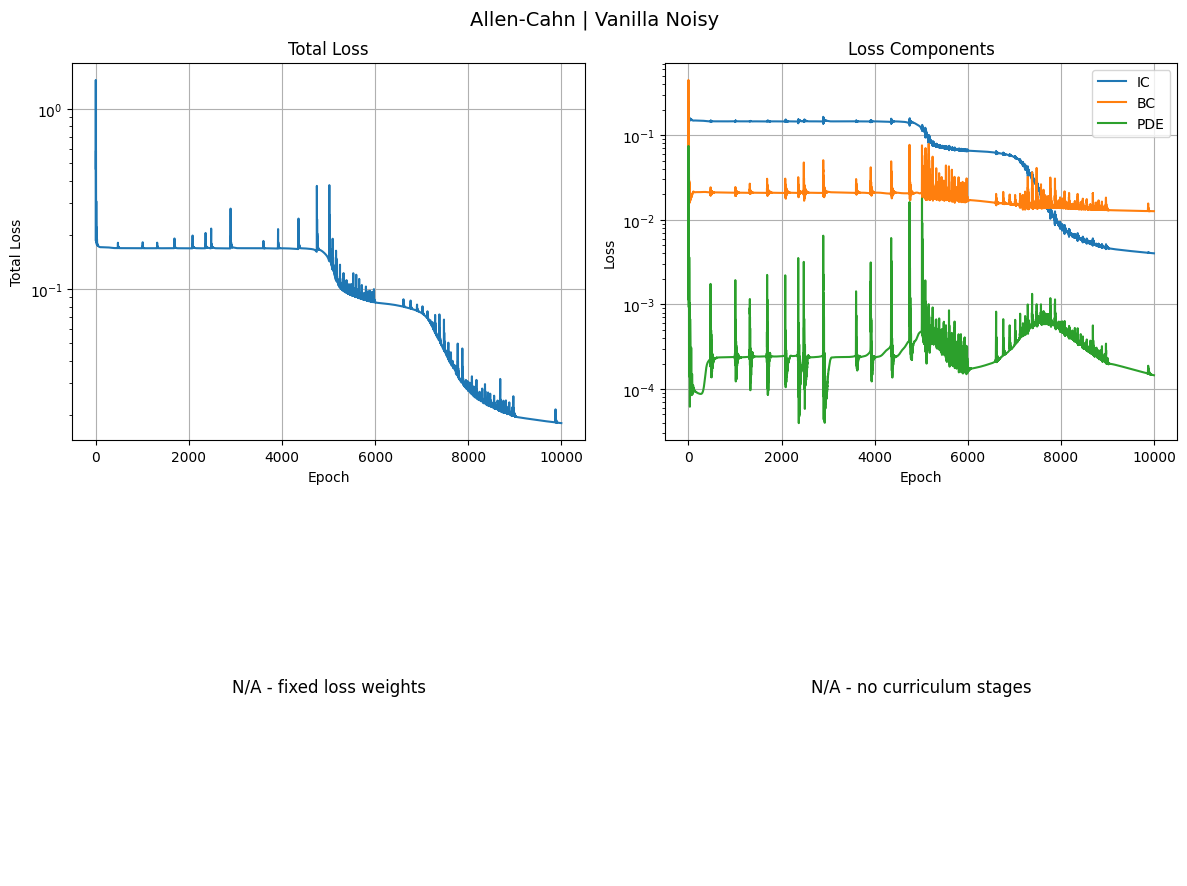

Saved: ../figures/allen_cahn/vanilla_noisy_training.png
Saved: ../figures/allen_cahn/vanilla_noisy_training.csv


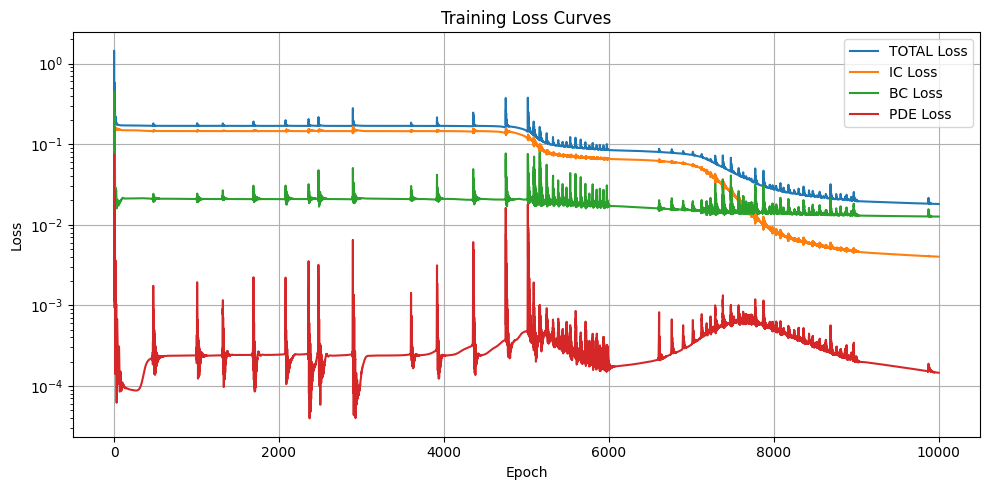

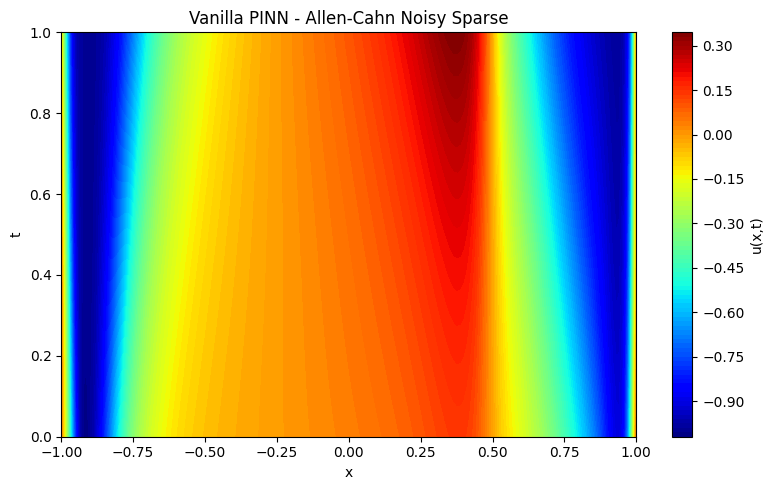

Saved: ../results/allen_cahn/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Allen-Cahn | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Allen-Cahn Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Allen-Cahn | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 0.184276 | IC: 0.151755 | BC: 0.029168 | PDE: 0.000671 | lam=(1.00,1.00,5.00)


[Allen-Cahn | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.028194 | IC: 0.004534 | BC: 0.008169 | PDE: 0.000025 | lam=(1.92,2.36,10.00)


[Allen-Cahn | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.011386 | IC: 0.001624 | BC: 0.000932 | PDE: 0.000022 | lam=(1.14,10.00,10.00)


[Allen-Cahn | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.043685 | IC: 0.020708 | BC: 0.002415 | PDE: 0.000033 | lam=(1.16,7.98,10.00)


[Allen-Cahn | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.001370 | IC: 0.000472 | BC: 0.000081 | PDE: 0.000003 | lam=(1.12,10.00,10.00)


...

[Allen-Cahn | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.000183 | IC: 0.000066 | BC: 0.000055 | PDE: 0.000000 | lam=(1.64,1.36,0.10)


[Allen-Cahn | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000091 | IC: 0.000033 | BC: 0.000028 | PDE: 0.000000 | lam=(1.60,1.38,0.10)


[Allen-Cahn | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.402124 | IC: 0.036442 | BC: 0.029476 | PDE: 0.172522 | lam=(0.46,0.37,2.17)


[Allen-Cahn | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.419123 | IC: 0.140076 | BC: 0.000155 | PDE: 0.000227 | lam=(2.99,0.10,0.10)



AC-PINN training complete in 271.81s


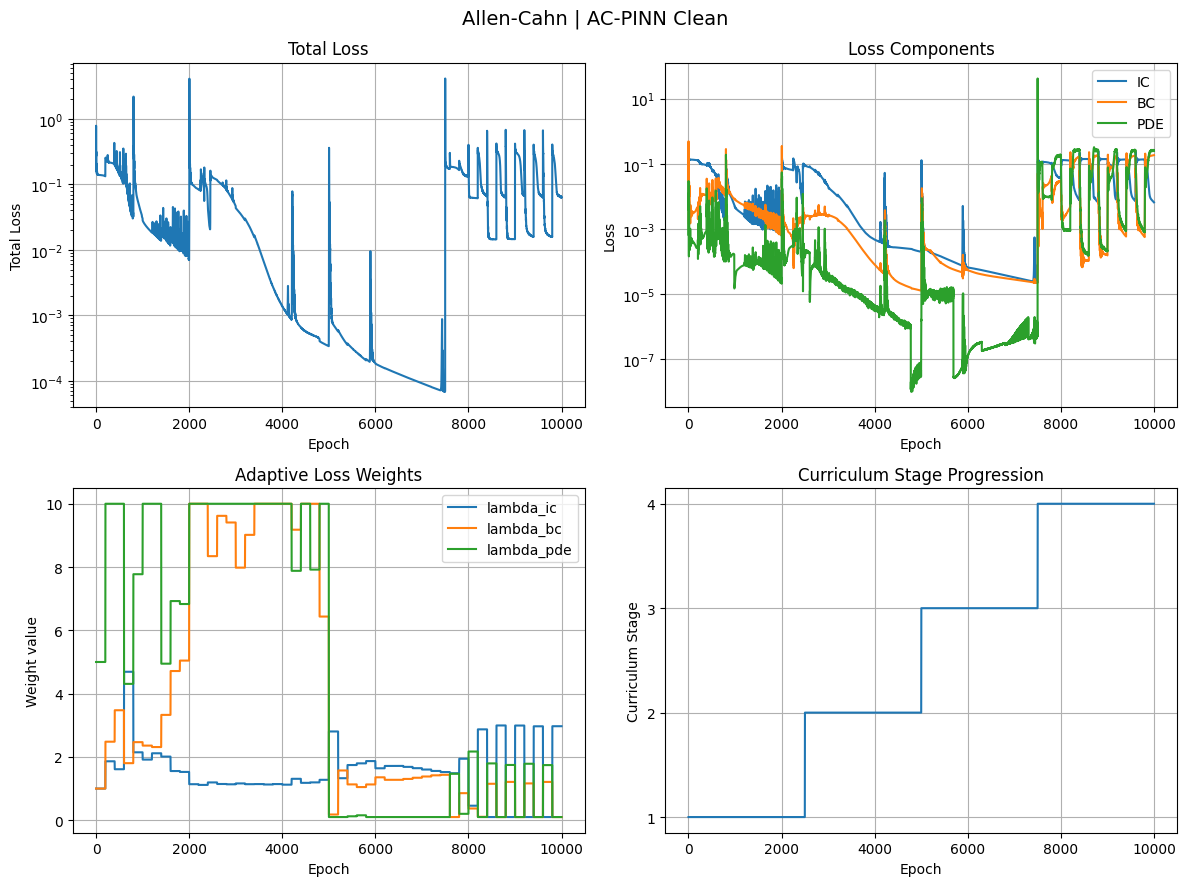

Saved: ../figures/allen_cahn/acpinn_clean_training.png
Saved: ../figures/allen_cahn/acpinn_clean_training.csv


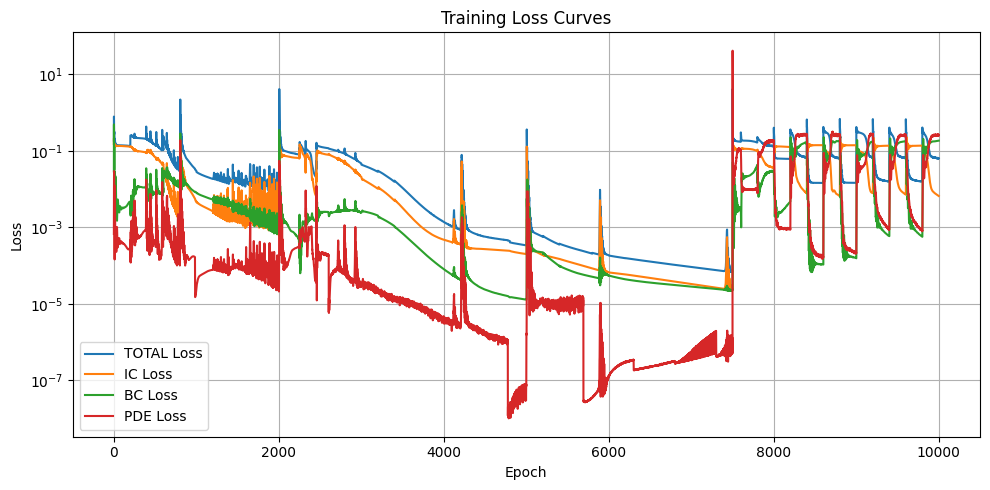

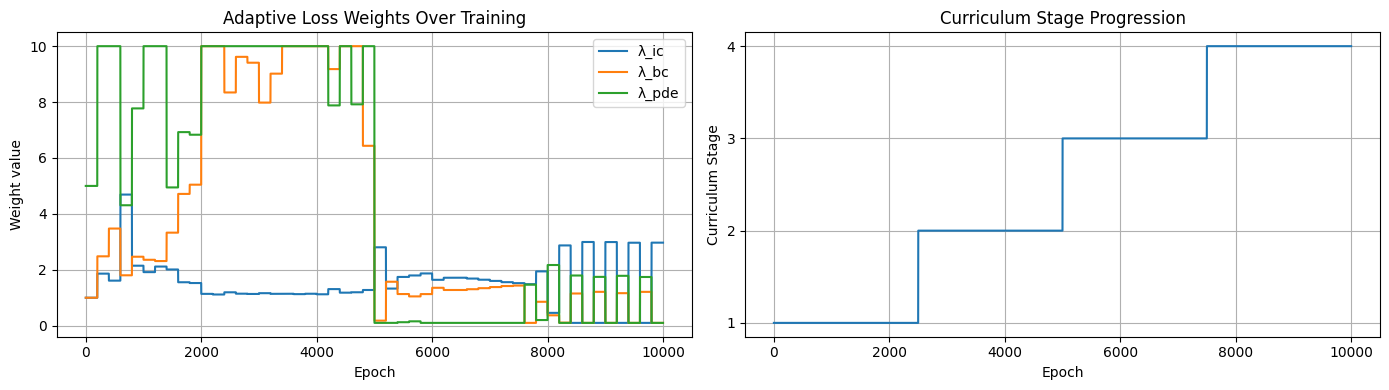

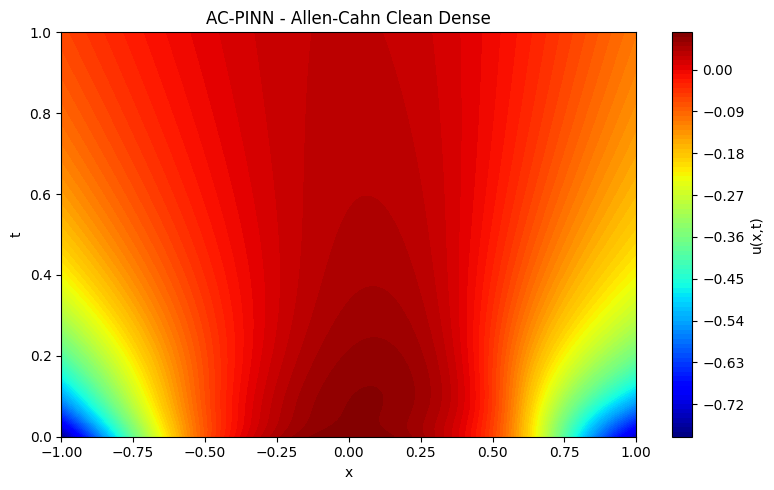

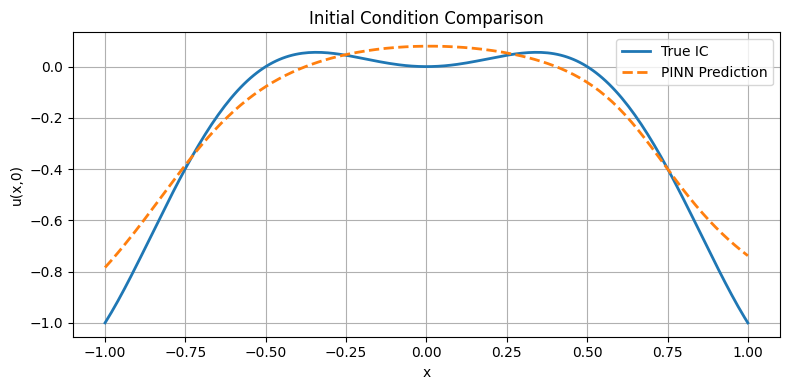

Saved: ../results/allen_cahn/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Allen-Cahn | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Allen-Cahn Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse
This is where AC-PINN should demonstrate its biggest advantage.

[Allen-Cahn | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.341652 | IC: 0.170632 | BC: 0.159001 | PDE: 0.002404 | lam=(1.00,1.00,5.00)


[Allen-Cahn | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.029696 | IC: 0.004451 | BC: 0.005645 | PDE: 0.000172 | lam=(2.62,3.09,3.39)


[Allen-Cahn | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.017273 | IC: 0.002939 | BC: 0.002766 | PDE: 0.000088 | lam=(3.94,1.92,4.44)


[Allen-Cahn | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.023389 | IC: 0.001703 | BC: 0.003267 | PDE: 0.000308 | lam=(10.00,1.64,3.29)


[Allen-Cahn | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.010643 | IC: 0.001115 | BC: 0.002198 | PDE: 0.000141 | lam=(3.69,2.80,2.69)


...

[Allen-Cahn | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.003417 | IC: 0.000322 | BC: 0.001504 | PDE: 0.000372 | lam=(0.44,2.05,0.51)


[Allen-Cahn | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.003533 | IC: 0.001449 | BC: 0.001133 | PDE: 0.000517 | lam=(1.40,1.10,0.50)


[Allen-Cahn | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.115338 | IC: 0.036340 | BC: 0.013458 | PDE: 0.047193 | lam=(1.12,0.42,1.46)


[Allen-Cahn | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.177830 | IC: 0.069934 | BC: 0.016143 | PDE: 0.000869 | lam=(2.41,0.56,0.10)



AC-PINN training complete in 149.95s


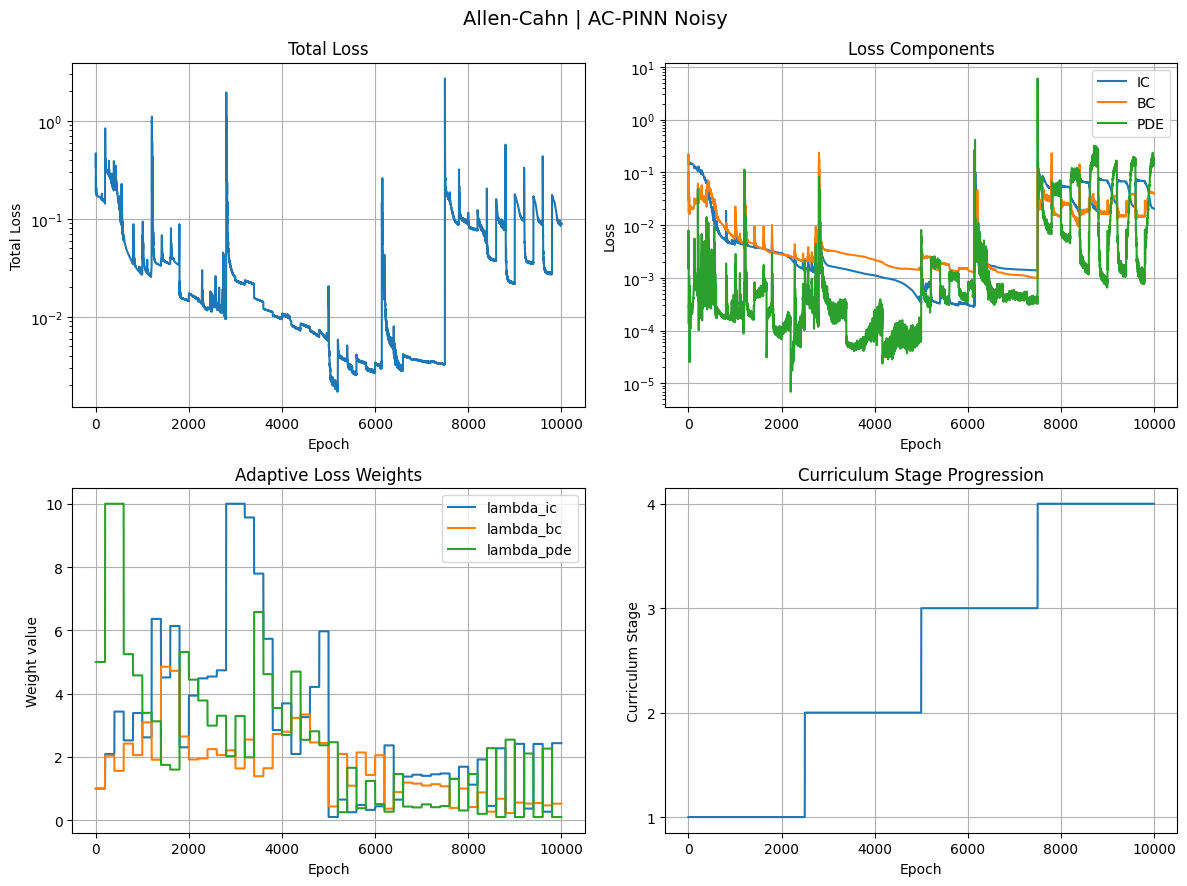

Saved: ../figures/allen_cahn/acpinn_noisy_training.png
Saved: ../figures/allen_cahn/acpinn_noisy_training.csv


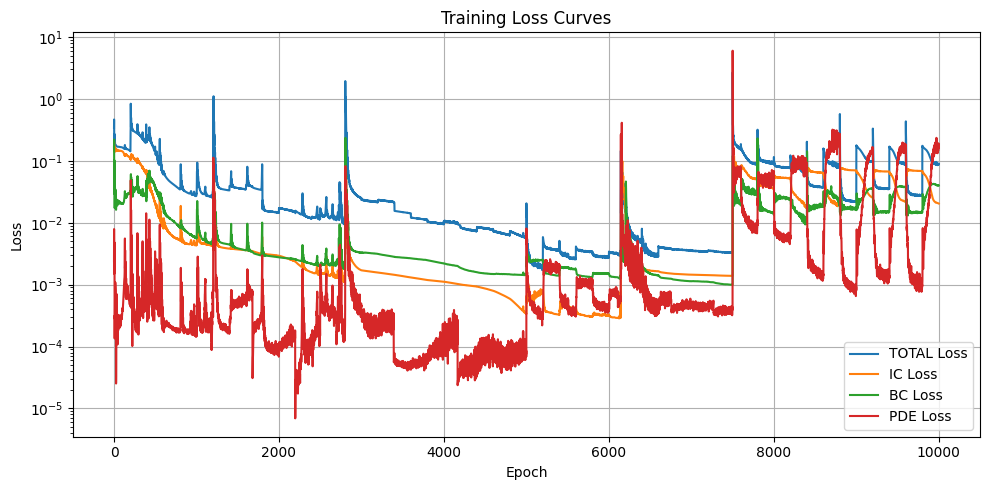

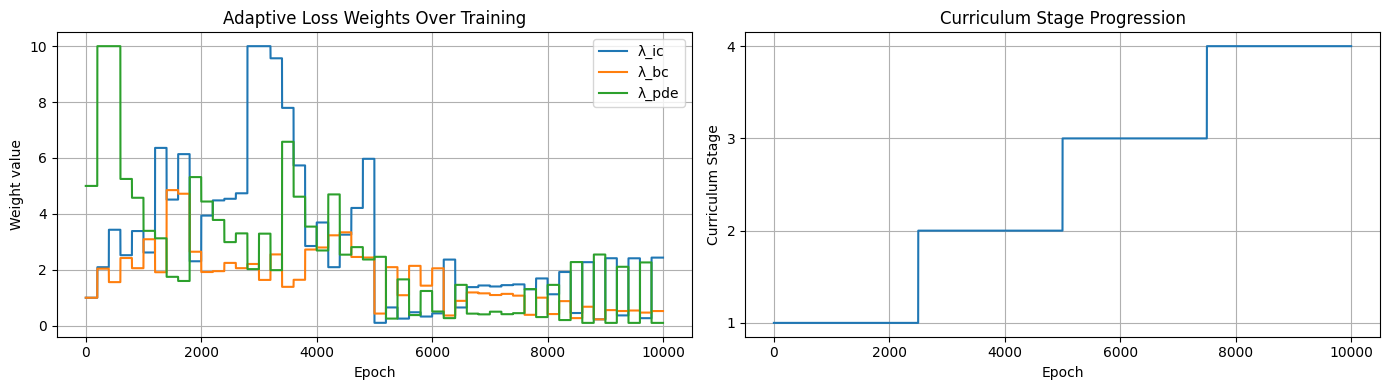

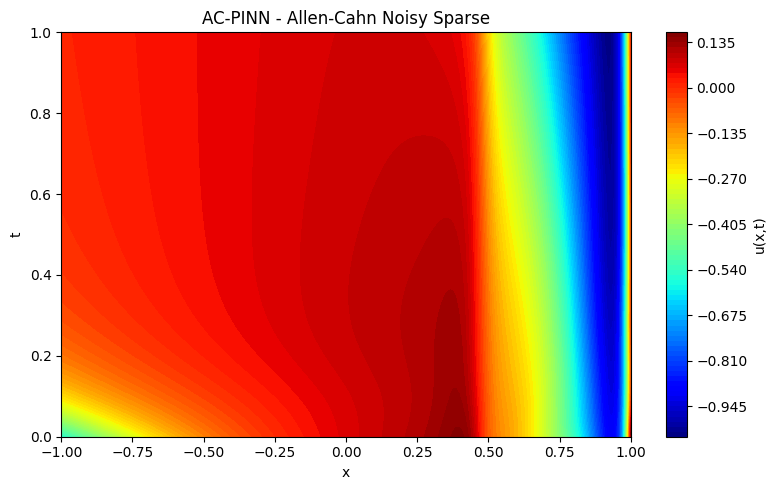

Saved: ../results/allen_cahn/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Allen-Cahn | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Allen-Cahn Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.121714   1.008458   0.029519   0.053356
  Vanilla (noisy)             0.255662   1.033814   0.082981   0.112075
  AC-PINN (clean)             0.797361   0.926120   0.224746   0.349540
  AC-PINN (noisy)             0.705779   1.119162   0.170960   0.309393


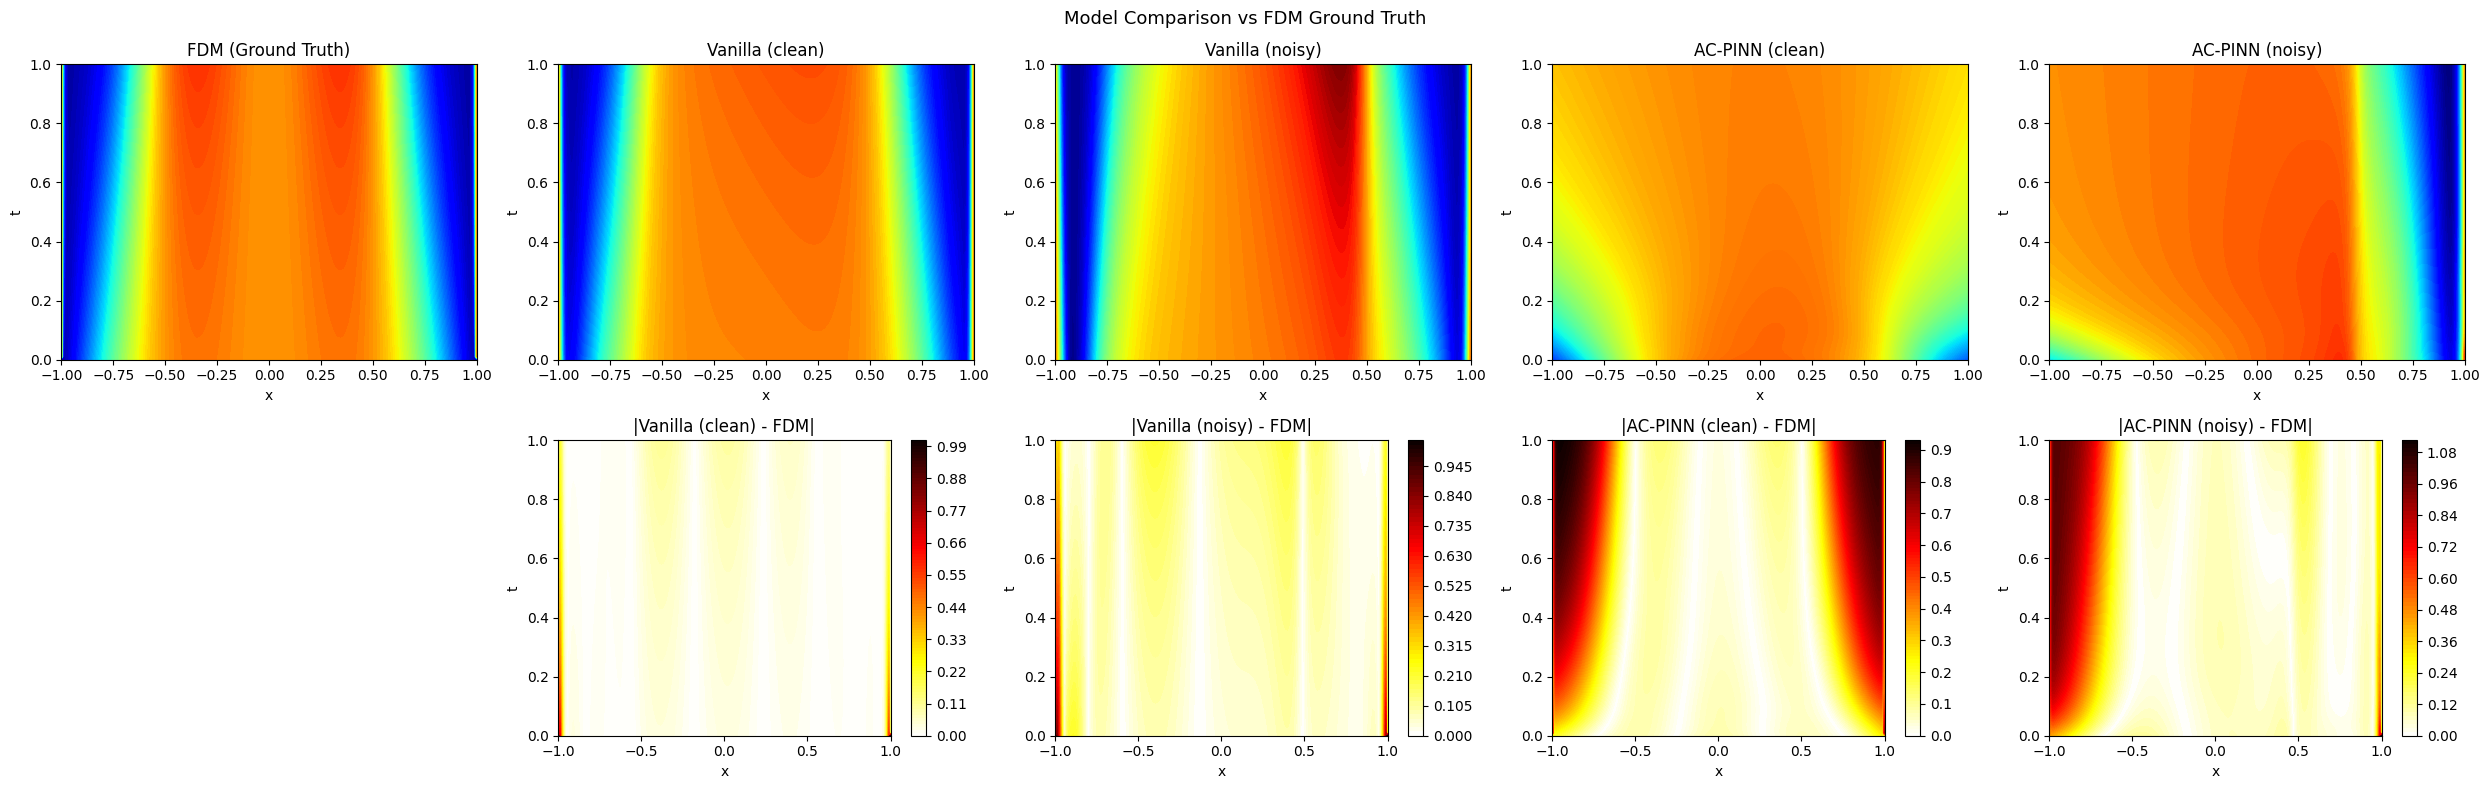

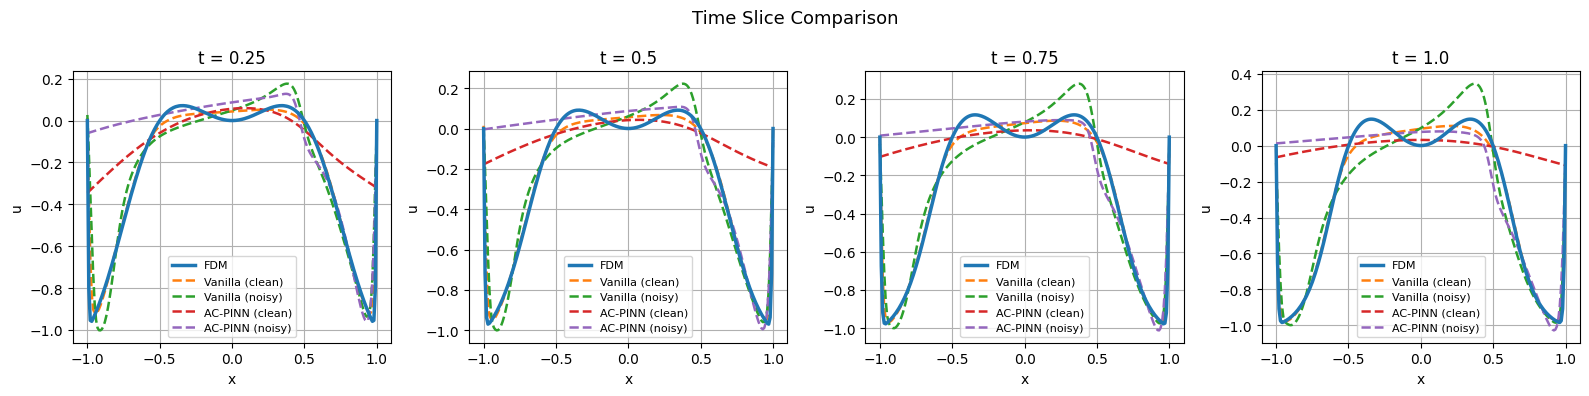

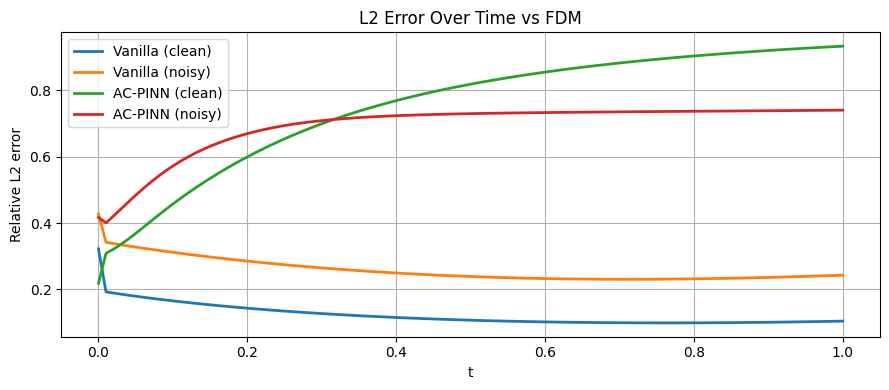

Saved: ../results/allen_cahn/benchmark_metrics.npy
Allen-Cahn experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Allen-Cahn experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=5000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, lambda_pde=10.0)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Allen-Cahn noise study complete.')


--- ε=0.05 ---
[Epoch     0/5000] Total: 1.271090 | IC: 0.132064 | BC: 0.161071 | PDE: 0.097795


[Epoch  2500/5000] Total: 0.136050 | IC: 0.120594 | BC: 0.012159 | PDE: 0.000330



Training complete in 78.63s
[Epoch     0/5000] Stage 1/4 | Total: 0.204719 | IC: 0.126135 | BC: 0.072706 | PDE: 0.001175 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.060144 | IC: 0.003735 | BC: 0.005401 | PDE: 0.003971 | lam=(10.00,1.44,3.79)



AC-PINN training complete in 84.94s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.918229   0.972041   0.289171   0.402525
  AC-PINN ε=0.05              0.899566   0.998016   0.253758   0.394344

--- ε=0.1 ---
[Epoch     0/5000] Total: 0.217607 | IC: 0.175153 | BC: 0.030318 | PDE: 0.001214


...


AC-PINN training complete in 84.74s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.484730   1.001785   0.109394   0.212491
  AC-PINN ε=0.1               0.436346   0.963881   0.094840   0.191282

--- ε=0.2 ---
[Epoch     0/5000] Total: 0.660401 | IC: 0.096757 | BC: 0.170199 | PDE: 0.039344


[Epoch  2500/5000] Total: 0.178338 | IC: 0.100727 | BC: 0.075411 | PDE: 0.000220



Training complete in 78.37s
[Epoch     0/5000] Stage 1/4 | Total: 0.299357 | IC: 0.096670 | BC: 0.194042 | PDE: 0.001729 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.350748 | IC: 0.034336 | BC: 0.068087 | PDE: 0.001986 | lam=(5.77,2.16,2.74)



AC-PINN training complete in 84.88s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.895651   0.959996   0.259110   0.392628
  AC-PINN ε=0.2               0.888130   0.967570   0.272320   0.389331
Saved: ../results/allen_cahn/noise_study_metrics.npy
Allen-Cahn noise study complete.
